In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'/Users/anirudhiyer/Desktop/Stress Prediction/Minor-Project/Datasets/preprocessed.csv')

In [3]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [4]:
df.drop(columns=['composite_score'],inplace=True)

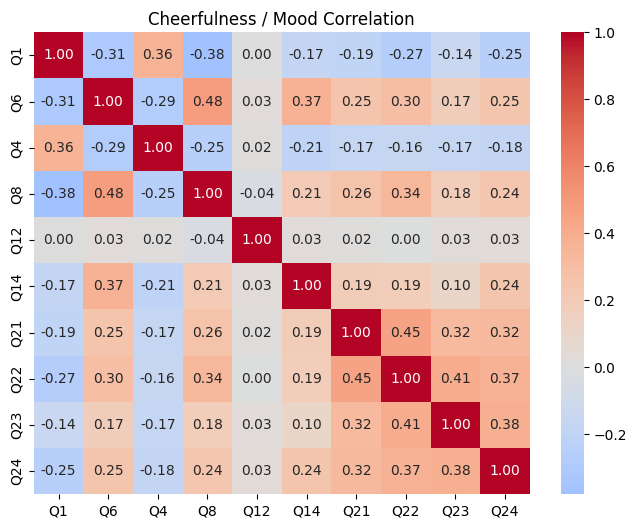

In [6]:
cheer_cols = ['Q1','Q6','Q4','Q8','Q12','Q14','Q21','Q22','Q23','Q24']

corr_cheer = df[cheer_cols].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(corr_cheer, annot=True, cmap='coolwarm', center=0,fmt='.2f')
plt.title("Cheerfulness / Mood Correlation")
plt.show()

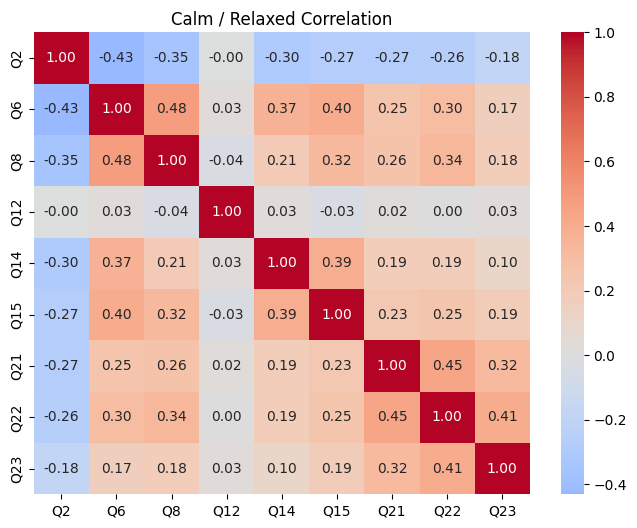

In [7]:
calm_cols = ['Q2','Q6','Q8','Q12','Q14','Q15','Q21','Q22','Q23']

corr_calm = df[calm_cols].corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(corr_calm, annot=True, cmap='coolwarm', center=0,fmt='.2f')
plt.title("Calm / Relaxed Correlation")
plt.show()

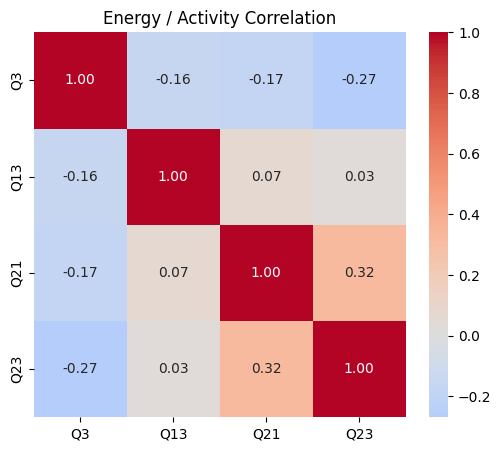

In [8]:
energy_cols = ['Q3','Q13','Q21','Q23']

corr_energy = df[energy_cols].corr(method='spearman')

plt.figure(figsize=(6,5))
sns.heatmap(corr_energy, annot=True, cmap='coolwarm', center=0,fmt='.2f')
plt.title("Energy / Activity Correlation")
plt.show()

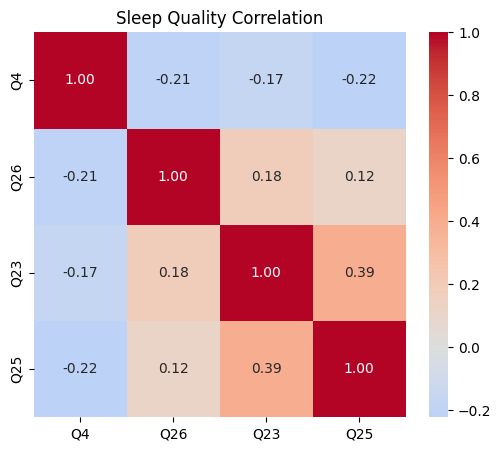

In [9]:
sleep_cols = ['Q4','Q26','Q23','Q25']

corr_sleep = df[sleep_cols].corr(method='spearman')

plt.figure(figsize=(6,5))
sns.heatmap(corr_sleep, annot=True, cmap='coolwarm', center=0,fmt='.2f')
plt.title("Sleep Quality Correlation")
plt.show()

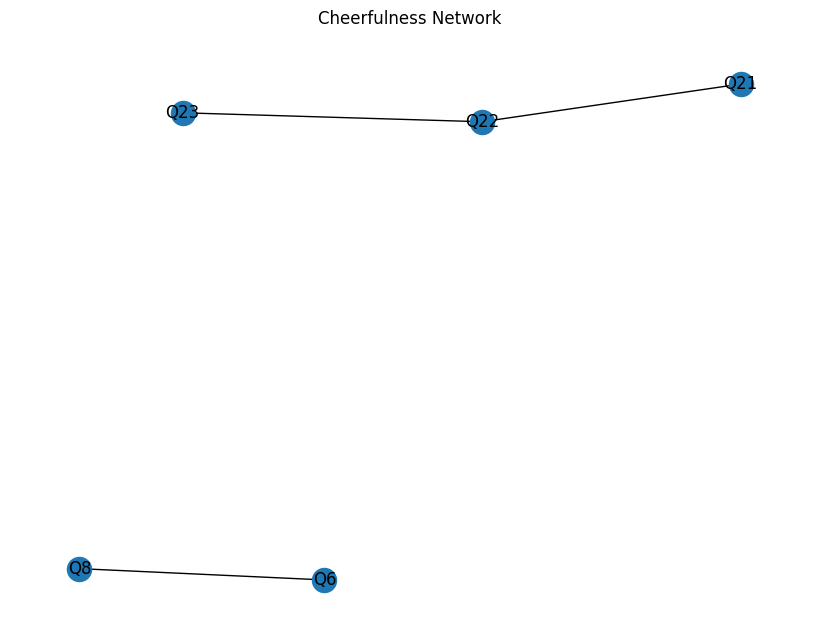

In [10]:
import networkx as nx
import numpy as np

corr = df[cheer_cols].corr(method='spearman')

G = nx.Graph()

for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i,j]) > 0.4:
            G.add_edge(i, j, weight=corr.loc[i,j])

plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True)
plt.title("Cheerfulness Network")
plt.show()

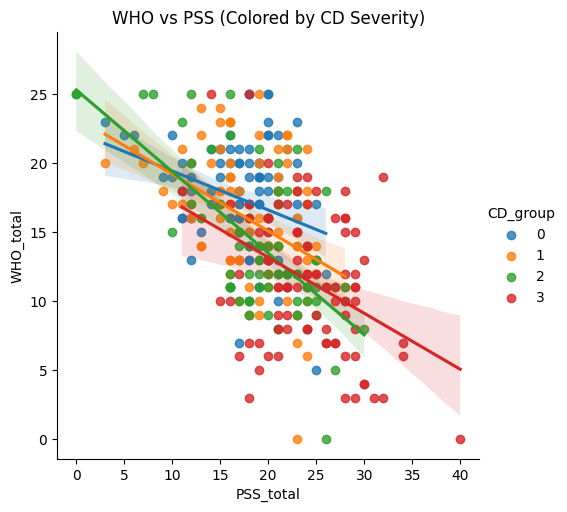

In [11]:
# totals (correct)
df['WHO_total'] = df[['Q1','Q2','Q3','Q4','Q5']].sum(axis=1)
df['PSS_total'] = df[['Q6','Q7','Q8','Q9','Q10','Q11','Q12','Q13','Q14','Q15']].sum(axis=1)

# CD numeric fix
cd_cols = ['Q21','Q22','Q23','Q24','Q25','Q26']
for col in cd_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['CD_total'] = df[cd_cols].sum(axis=1)

# safe grouping
df['CD_group'] = pd.qcut(df['CD_total'], 4, labels=False, duplicates='drop')

sns.lmplot(x='PSS_total', y='WHO_total', hue='CD_group', data=df)
plt.title("WHO vs PSS (Colored by CD Severity)")
plt.show()

1. As perceived stress increases, overall wellbeing decreases.
2. Individuals with higher CDSIMER severity experience a stronger negative impact of stress on wellbeing
3. CDSIMER is acting as a mediating psychological factor

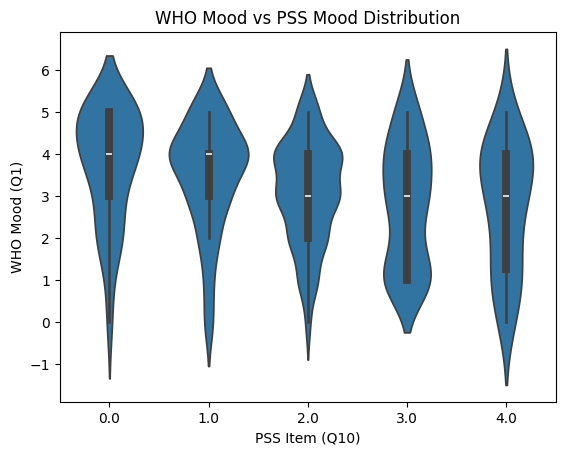

In [12]:
sns.violinplot(x='Q10', y='Q1', data=df)
plt.xlabel("PSS Item (Q10)")
plt.ylabel("WHO Mood (Q1)")
plt.title("WHO Mood vs PSS Mood Distribution")
plt.show()

1. While higher perceived stress is associated with reduced mood, variability suggests individual differences in coping mechanisms.

/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Desktop/Stress Prediction/ml_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/anirudhiyer/Deskt

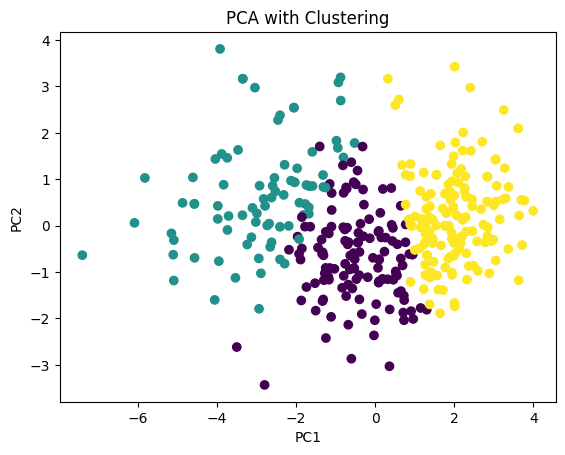

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

selected_cols = [
    'Q1','Q2','Q3','Q4',
    'Q6','Q8','Q12','Q14','Q15','Q13',
    'Q21','Q22','Q23','Q24','Q25','Q26'
]

# numeric conversion
for col in selected_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

X = df[selected_cols].dropna()
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with Clustering")
plt.show()

1. Clear separation of groups are visible 
2. Some overalps do exist suggesting Mental health is not discrete, but continuous


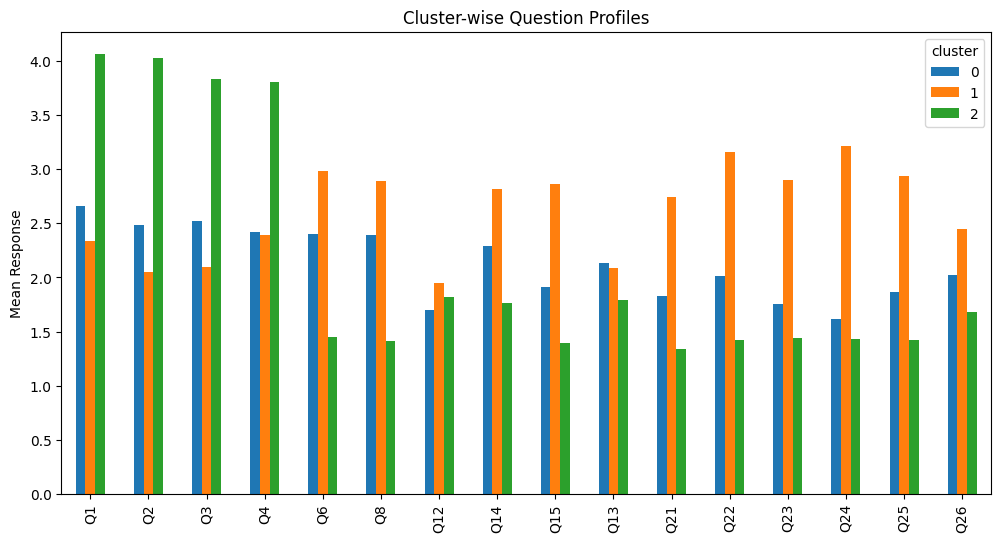

In [14]:
df_clean = df[selected_cols].dropna().copy()
df_clean['cluster'] = clusters

cluster_means = df_clean.groupby('cluster').mean().T

cluster_means.plot(kind='bar', figsize=(12,6))
plt.title("Cluster-wise Question Profiles")
plt.ylabel("Mean Response")
plt.show()

1. Individuals with high wellbeing, low stress, low CD symptoms. (Cluster Green)
2. Individuals with high stress and high CD severity. (Cluster Orange)
3. Individuals in a balanced or transitional psychological state (Cluster Blue)

### Clustering based on given sequence